In [2]:
# HURLING MATCH ANALYSIS - FULL TEMPLATE NOTEBOOK

In [3]:
# CONFIG - Edit first before running notebook

MATCH_LABEL = '2025_AIHF_CORK_TIPP'
MATCH_TITLE = '2025 All-Ireland Hurling Final'
TEAM_A = 'Cork'
TEAM_B = 'Tipperary'
RESULT = 'Tipperary 3-27  Cork 1-18 (Tipp Win)'
COLOUR_A = '#e05050'
COLOUR_B = '#003DA5'

PO_PATH = f'https://raw.githubusercontent.com/tdraths/hurling-match-data/refs/heads/main/data/processed/puckouts/processed_puckouts_{MATCH_LABEL}.csv'
FR_PATH = f'https://raw.githubusercontent.com/tdraths/hurling-match-data/refs/heads/main/data/processed/frees/processed_frees_{MATCH_LABEL}.csv'

FREE_TAKERS = {}
CONTEXT_NOTE = (
    "Match outcome driven by 3 Tipperary goals."
    "Tipperary outperformed Cork on all puckout process metrics."
    "Cork led at the half by 6 points, but fell behind early in the second half and did not recover."
)

In [4]:
# IMPORTS & SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

C_GREEN = '#2d8a4e'
C_RED   = '#e05050'
C_GOLD  = '#f5c842'
C_GREY  = '#888888'
C_GRASS = '#e8f4e8'
TEAMS   = [TEAM_A, TEAM_B]
COLOURS = [COLOUR_A, COLOUR_B]

sns.set_theme(style='whitegrid', font='sans-serif')

PL = dict(
    template = 'plotly_white',
    font = dict(family='Arial', size=12, color='#333333'),
    paper_bgcolor = 'white', plot_bgcolor = 'white',
    margin = dict(t=60, b=40, l=50, r=30),
)

PO_ZONES = {
    'AL':(0,0),'AC':(0,1),'AR':(0,2),
    'ML':(1,0),'MC':(1,1),'MR':(1,2),
    'DL':(2,0),'DC':(2,1),'DR':(2,2),
}
ZONE_TO_TYPE = {
    'DL':'short','DC':'short','DR':'short',
    'ML':'medium','MC':'medium','MR':'medium',
    'AL':'long','AC':'long','AR':'long',
}
GS_ORDER = ['Losing 4+','Losing 1-3','Level','Winning 1-3','Winning 4+']
POSS_VALUE = {'point':1,'goal':3,'no-score':0,'opp-point':-1,'opp-goal':-3}

print("Imports and setup complete")

Imports and setup complete


In [5]:
# LOAD & DERIVE

po = pd.read_csv(PO_PATH)
fr = pd.read_csv(FR_PATH)

po['type'] = po['target_zone'].map(ZONE_TO_TYPE).fillna('unknown')
po['retained_bool'] = po['retained'] == 'yes'

po['has_chain'] = (
    po['t1_action'].notna() &
    (po['t1_action'].astype(str).str.strip() != '') &
    (po['t1_action'].astype(str).str.strip() != 'unknown')
)

def get_chain_length(row):
    if not row['has_chain']:
        return 0
    length = 0
    for n in [1,2,3]:
        val = str(row.get(f't{n}_action','')).strip()
        if val and val not in ('','n/a','nan','unknown'):
            length = n
    return length

po['chain_length'] = po.apply(get_chain_length, axis=1)

chain_po = po[po['has_chain']].copy()

chain_po['is_stl'] = (
    (chain_po['type']=='short') & (
        (chain_po['t1_action']=='launch') |
        ((chain_po['t1_action']=='pass') & (chain_po['t2_action']=='launch'))
    )
)
chain_po['has_shot']     = chain_po[['t1_action','t2_action','t3_action']].isin(['shot']).any(axis=1)
chain_po['shot_scored']  = chain_po['shot_outcome'].isin(['point','goal'])
chain_po['has_turnover'] = chain_po[['t1_action','t2_action','t3_action']].isin(['turnover']).any(axis=1)

po['net_score_value'] = po['poss_outcome'].map(POSS_VALUE)
po['outcome_logged']  = po['poss_outcome'].notna() & (po['poss_outcome'] != '')

def gs_bin(d):
    """Converts numeric score diff to a human-readable game state label."""
    if d<=-4: return 'Losing 4+'
    elif d<=-1: return 'Losing 1-3'
    elif d==0: return 'Level'
    elif d<=3: return 'Winning 1-3'
    else: return 'Winning 4+'

po['game_state'] = po['score_diff'].apply(gs_bin)

sub_po    = {t: po[po['pucking_team']==t]        for t in TEAMS}
sub_chain = {t: chain_po[chain_po['pucking_team']==t] for t in TEAMS}

fr['scored']      = fr['outcome'].isin(['point','goal'])
fr['score_value'] = fr['outcome'].map({'point':1,'goal':3}).fillna(0)
for team, player in FREE_TAKERS.items():
    fr.loc[fr['shooting_team']==team, 'shooter'] = player
sub_fr = {t: fr[fr['shooting_team']==t] for t in TEAMS}

retained_chain = chain_po[chain_po['retained']=='yes']

print(f"Loaded {len(po)} puckouts, {len(fr)} frees")
print(f"Chain coverage: {po['has_chain'].sum()}/{len(po)} ({po['has_chain'].mean()*100:.0f}%)")
print(f"Outcome logged: {po['outcome_logged'].sum()}/{len(po)} ({po['outcome_logged'].mean()*100:.0f}%)")

Loaded 73 puckouts, 32 frees
Chain coverage: 66/73 (90%)
Outcome logged: 73/73 (100%)


In [6]:
# DATA HEALTH REPORT
W = 58
print('='*W)
print(f'  DATA HEALTH - {MATCH_LABEL}')
print('='*W)
checks = [
    ('Puckouts',            len(po),                                    '-'),
    ('Frees',               len(fr),                                    '-'),
    ('Unknown zones',       (po['target_zone']=='unknown').sum(),       'ideally 0'),
    ('Unknown delivery',    (po['delivery']=='unknown').sum(),          'idealy 0'),
    ('Unknown retained',    (po['retained']=='unknown').sum(),          'ideally 0'),
    ('Bad puckout minutes', po['minute'].isna().sum(),                  'should be 0'),
    ('Bad free minutes',    fr['minute'].isna().sum(),                  'should be 0'),
    ('Chain coverage',      f"{po['has_chain'].sum()}/{len(po)} ({po['has_chain'].mean()*100:.0f}%)", 'aim >80%'),
    ("Outcome logged",      f"{po['outcome_logged'].sum()}/{len(po)} ({po['outcome_logged'].mean()*100:.0f}%)", "aim 100%"),
    ("Net score NaN",       po['net_score_value'].isna().sum(),         "should be 0"),
]

print(f"\n {'Check':<32} {'Value':>12} {'Target':>10}")
print(f" {'-'*54}")
for label, val, target in checks:
    print(f" {label:<32} {str(val):>12} {target:>10}")
print(f"\n poss_outcome distribution:")
for val, cnt in po['poss_outcome'].value_counts(dropna=False).items():
    lbl = str(val) if pd.notna(val) else '(empty)'
    nv = POSS_VALUE.get(str(val), '-')
    print(f" {lbl:<15} {cnt:>4} ({cnt/len(po)*100:.0f}%) value={nv}")
print('='*W)

  DATA HEALTH - 2025_AIHF_CORK_TIPP

 Check                                   Value     Target
 ------------------------------------------------------
 Puckouts                                   73          -
 Frees                                      32          -
 Unknown zones                               0  ideally 0
 Unknown delivery                            1   idealy 0
 Unknown retained                            0  ideally 0
 Bad puckout minutes                         2 should be 0
 Bad free minutes                            0 should be 0
 Chain coverage                    66/73 (90%)   aim >80%
 Outcome logged                   73/73 (100%)   aim 100%
 Net score NaN                               0 should be 0

 poss_outcome distribution:
 no-score          45 (62%) value=0
 point             19 (26%) value=1
 opp-point          8 (11%) value=-1
 goal               1 (1%) value=3


In [7]:
# MATCH SUMMARY SCORECARD

def safe_pct(p, mask):
    s = p[mask]
    return f"{s.mean()*100:.0f}%" if len(s)>0 else '-'

metrics = [
    'Puckouts','Retention %',
    'Short puckouts','Short retention %',
    'Long puckouts','Long retention %',
    'Clean deliveries %','Broken deliveries %',
    'Net score value (mean)','Net score value (total)',
    'Free attempts','Free conversion %','Chain coverage %',
]

def team_vals(team):
    p = sub_po[team]; f = sub_fr[team]
    return [
        len(p),
        f"{p['retained_bool'].mean()*100:.0f}%",
        (p['type']=='short').sum(),
        safe_pct(p['retained_bool'], p['type']=='short'),
        (p['type']=='long').sum(),
        safe_pct(p['retained_bool'], p['type']=='long'),
        f"{(p['delivery']=='C').mean()*100:.0f}%",
        f"{(p['delivery']=='B').mean()*100:.0f}%",
        f"{p['net_score_value'].mean():+.2f}",
        f"{p['net_score_value'].sum():+.0f}",
        len(f),
        f"{f['scored'].mean()*100:.0f}%",
        f"{p['has_chain'].mean()*100:.0f}%",
    ]

fig = go.Figure(data=[go.Table(
    columnwidth=[240,110,110],
    header=dict(
        values=['<b>Metric</b>',f'<b>{TEAM_A}</b>',f'<b>{TEAM_B}</b>'],
        fill_color=['#f0f0f0',COLOUR_A,COLOUR_B],
        font=dict(color=['#333','white','white'],size=13),
        align='center', height=36,
    ),
    cells=dict(
        values=[metrics, team_vals(TEAM_A), team_vals(TEAM_B)],
        fill_color=['#f9f9f9',
                    ['#f5f5f5' if i%2==0 else 'white' for i in range(len(metrics))],
                    ['#f5f5f5' if i%2==0 else 'white' for i in range(len(metrics))]],
        font=dict(color='#333',size=12),
        align=['left','center','center'], height=30,
    )
)])

fig.update_layout(
    title=f'<b>{MATCH_TITLE} — Process Metrics Scorecard</b><br><sup>{RESULT}</sup>',
    title_font_size=15, height=480, **PL)
fig.show()

In [8]:
# PUCKOUT STRATEGY

types = ['short', 'medium', 'long']
fig   = make_subplots(rows=1, cols=3,
    subplot_titles=('<b>Type Distribution</b>',
                    '<b>Retention % by Type</b>',
                    '<b>Next Action (retained)</b>'),
    horizontal_spacing=0.1)

for i, (team, col) in enumerate(zip(TEAMS, COLOURS)):
    p = sub_po[team]
    pcts = [(p['type']==t).mean()*100 for t in types]
    fig.add_trace(go.Bar(name=team, x=[t.title() for t in types],
                         y=[round(v,1) for v in pcts], marker_color=col,
                         text=[f'{v:.0f}%' for v in pcts], textposition='outside',
                         offsetgroup=i, showlegend=True, dx=1, dy=1))

for team,col in zip(TEAMS,COLOURS):
    p = sub_po[team]; xs,ys = [],[]
    for t in types:
        s = p[p['type']==t]
        if len(s)>=2:
            xs.append(t.title())
            ys.append(round(s['retained_bool'].mean()*100,1))
    fig.add_trace(go.Scatter(name=team,x=xs,y=ys,
        mode='lines+markers+text',
        line=dict(color=col,width=2.5),marker=dict(size=10,color=col),
        text=[f'{v:.0f}%' for v in ys],textposition='top center',
        showlegend=False), row=1, col=2)

actions = ['shot', 'pass', 'launch', 'carry', 'turnover', 'foul-won']
act_cols = [C_GOLD,'#5090e0','#c6f135',C_GREY,C_RED,'#e08830']
for i,(team,col) in enumerate(zip(TEAMS,COLOURS)):
    retained = sub_po[team][sub_po[team]['retained']=='yes']
    total    = len(retained)
    if total==0: continue
    for action,acol in zip(actions,act_cols):
        cnt = (retained['next_action']==action).sum()
        if cnt>0:
            fig.add_trace(go.Bar(name=action.title(),x=[team],
                y=[cnt/total*100],marker_color=acol,
                text=[f'{action}<br>{cnt/total*100:.0f}%'] if cnt/total>0.06 else [''],
                textposition='inside',showlegend=(i==0),offsetgroup=i),
                row=1, col=3)

fig.update_layout(barmode='stack',
    yaxis=dict(title='% of puckouts',range=[0,90]),
    yaxis2=dict(title='Retention %',range=[0,115]),
    yaxis3=dict(title='% retained puckouts',range=[0,110]),
    legend=dict(orientation='h',y=1.12,x=0.5,xanchor='center'),
    title=f'<b>{MATCH_TITLE} — Puckout Strategy</b>',
    title_font_size=15, height=440, **PL)
fig.show()

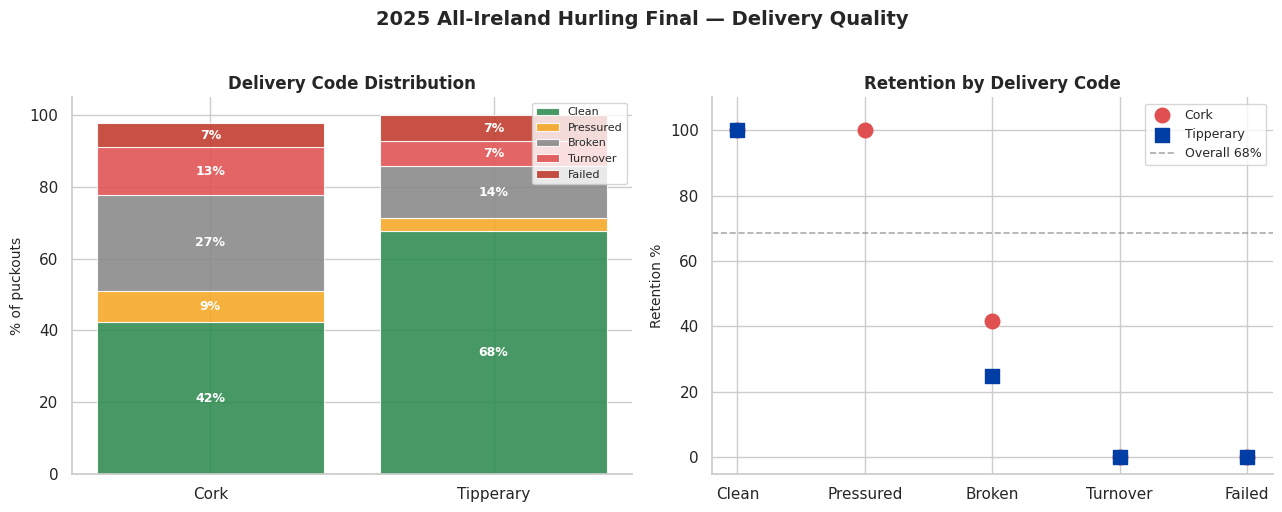

Broken ball: 16/73 (22%)


In [9]:
# DELIVERY CODE ANALYSIS

DEL_ORDER  = ['C','P','B','T','X']
DEL_LABELS = ['Clean','Pressured','Broken','Turnover','Failed']
DEL_COLS   = [C_GREEN,'#f5a623',C_GREY,C_RED,'#c0392b']

fig2, axes = plt.subplots(1,2,figsize=(13,5))
fig2.patch.set_facecolor('white')

ax = axes[0]
bottom = np.zeros(len(TEAMS))
for code,label,col in zip(DEL_ORDER,DEL_LABELS,DEL_COLS):
    vals = np.array([(sub_po[t]['delivery']==code).mean()*100 for t in TEAMS])
    ax.bar(TEAMS,vals,bottom=bottom,color=col,alpha=0.88,
           edgecolor='white',linewidth=0.8,label=label)
    for xi,(v,b) in enumerate(zip(vals,bottom)):
        if v>5:
            ax.text(xi,b+v/2,f'{v:.0f}%',ha='center',va='center',
                    fontsize=9,fontweight='bold',color='white')
    bottom += vals
ax.set_ylabel('% of puckouts',fontsize=10)
ax.set_title('Delivery Code Distribution',fontsize=12,fontweight='bold')
ax.legend(loc='upper right',fontsize=8)
ax.set_facecolor('white'); ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
for team,col,marker in zip(TEAMS,COLOURS,['o','s']):
    xs,ys = [],[]
    for code,label in zip(DEL_ORDER,DEL_LABELS):
        s = sub_po[team][sub_po[team]['delivery']==code]
        if len(s)>=2:
            xs.append(label)
            ys.append(s['retained_bool'].mean()*100)
    ax2.scatter(xs,ys,color=col,s=110,marker=marker,zorder=5,label=team)
ax2.axhline(po['retained_bool'].mean()*100,color=C_GREY,linestyle='--',
            linewidth=1.2,alpha=0.7,label=f"Overall {po['retained_bool'].mean()*100:.0f}%")
ax2.set_ylabel('Retention %',fontsize=10)
ax2.set_title('Retention by Delivery Code',fontsize=12,fontweight='bold')
ax2.legend(fontsize=9); ax2.set_ylim(-5,110)
ax2.set_facecolor('white'); ax2.spines[['top','right']].set_visible(False)

plt.suptitle(f'{MATCH_TITLE} — Delivery Quality',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{MATCH_LABEL}_delivery.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print(f"Broken ball: {(po['delivery']=='B').sum()}/{len(po)} ({(po['delivery']=='B').mean()*100:.0f}%)")

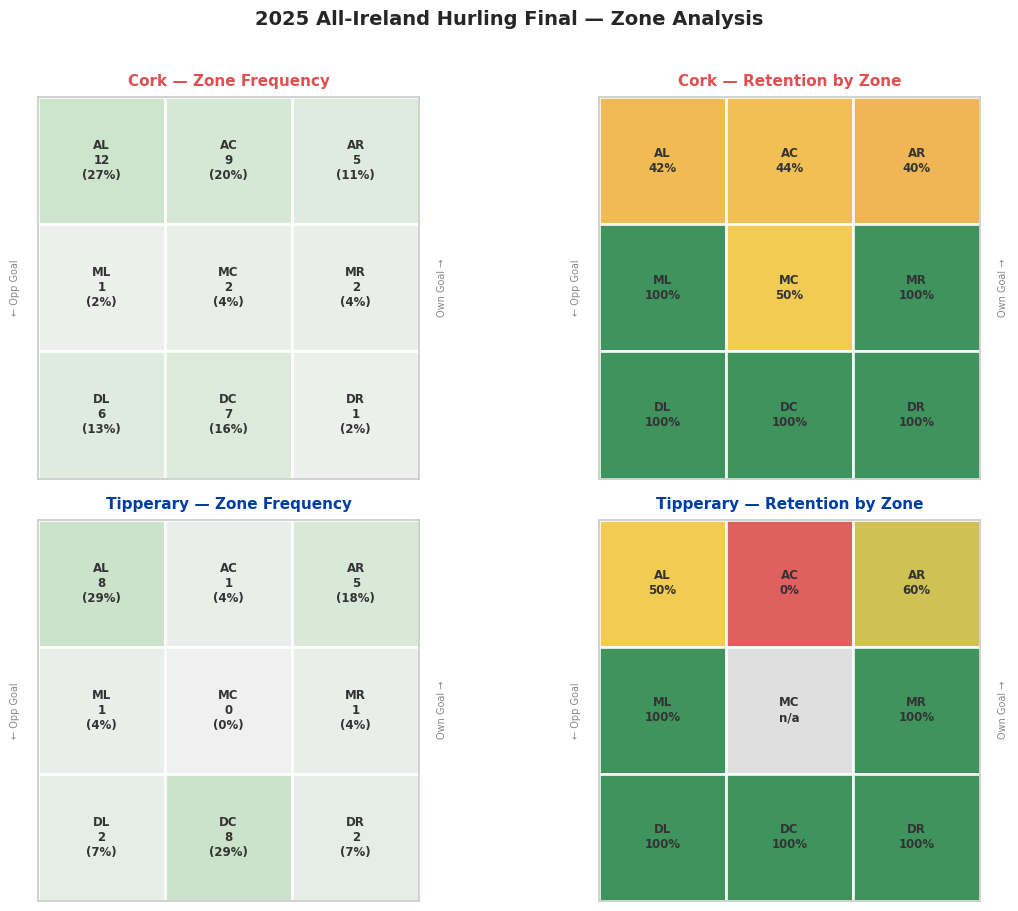

In [10]:
# FREQUENCY & RETENTION

rg_cmap   = LinearSegmentedColormap.from_list('rg',['#e05050','#f5c842','#2d8a4e'])
fig3,axes = plt.subplots(2,2,figsize=(12,9))
fig3.patch.set_facecolor('white')

for row_i,(team,col_t) in enumerate(zip(TEAMS,COLOURS)):
    sub         = sub_po[team]
    total       = len(sub)
    zone_counts = sub['target_zone'].value_counts()
    zone_ret    = {z: sub[sub['target_zone']==z]['retained_bool'].mean()
                   if len(sub[sub['target_zone']==z])>0 else np.nan
                   for z in PO_ZONES}
    freq_cmap   = LinearSegmentedColormap.from_list('freq',['#f0f0f0','#a8d8a8',col_t])

    for col_i,(data_dict,suffix,cmap) in enumerate([
        ({z: zone_counts.get(z,0)/total for z in PO_ZONES},'Zone Frequency',freq_cmap),
        (zone_ret,'Retention by Zone',rg_cmap),
    ]):
        ax = axes[row_i][col_i]
        ax.set_facecolor(C_GRASS); ax.set_xlim(0,3); ax.set_ylim(0,3); ax.set_aspect('equal')
        for zone,(row,col) in PO_ZONES.items():
            val    = data_dict.get(zone,np.nan)
            is_nan = isinstance(val,float) and np.isnan(val)
            colour = cmap(val) if not is_nan else '#dddddd'
            ax.add_patch(patches.Rectangle((col,2-row),1,1,
                facecolor=colour,alpha=0.9,edgecolor='white',linewidth=2))
            if col_i==0:
                cnt = zone_counts.get(zone,0)
                lbl = f"{zone}\n{cnt}\n({val*100:.0f}%)"
            else:
                lbl = f"{zone}\n{val*100:.0f}%" if not is_nan else f"{zone}\nn/a"
            ax.text(col+0.5,2-row+0.5,lbl,ha='center',va='center',
                    fontsize=8.5,fontweight='bold',color='#333333')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{team} — {suffix}',fontsize=11,fontweight='bold',color=col_t,pad=8)
        ax.text(-0.06, 0.5, '← Opp Goal', transform=ax.transAxes,
        fontsize=7, color=C_GREY, ha='center', va='center', rotation=90)
        ax.text(1.06, 0.5, 'Own Goal →', transform=ax.transAxes,
        fontsize=7, color=C_GREY, ha='center', va='center', rotation=90)

plt.suptitle(f'{MATCH_TITLE} — Zone Analysis',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig(f'{MATCH_LABEL}_zones.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

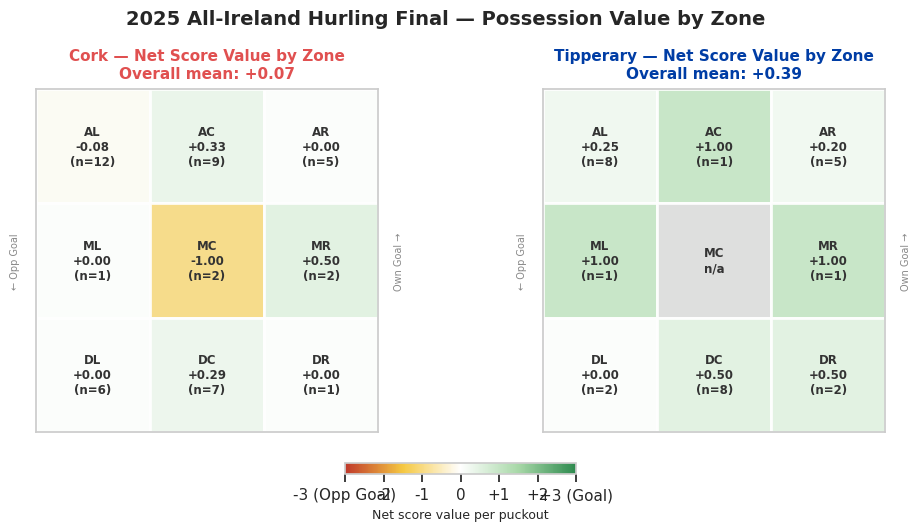


Net score value by type:
                     mean  count  sum
pucking_team type                    
Cork         long    0.08     26    2
             medium -0.20      5   -1
             short   0.14     14    2
Tipperary    long    0.29     14    4
             medium  1.00      2    2
             short   0.42     12    5


In [11]:
# POSSESSION VALUE BY ZONE

pv_cmap = LinearSegmentedColormap.from_list(
    'pv',['#c0392b','#f5c842','white','#a8d8a8','#2d8a4e'],N=256)

fig4,axes = plt.subplots(1,2,figsize=(12,5))
fig4.patch.set_facecolor('white')

for ax_i,(team,col_t) in enumerate(zip(TEAMS,COLOURS)):
    sub = sub_po[team]
    ax  = axes[ax_i]
    ax.set_facecolor(C_GRASS); ax.set_xlim(0,3); ax.set_ylim(0,3); ax.set_aspect('equal')

    for zone,(row,col) in PO_ZONES.items():
        s      = sub[(sub['target_zone']==zone) & sub['outcome_logged']]
        is_nan = len(s)==0
        val    = s['net_score_value'].mean() if not is_nan else np.nan

        # Normalise -3 to +3 range onto 0-1 for colourmap
        colour = pv_cmap((val+3)/6) if not is_nan else '#dddddd'
        cnt    = len(sub[sub['target_zone']==zone])

        ax.add_patch(patches.Rectangle((col,2-row),1,1,
            facecolor=colour,alpha=0.9,edgecolor='white',linewidth=2))
        lbl = f"{zone}\n{val:+.2f}\n(n={cnt})" if not is_nan else f"{zone}\nn/a"
        ax.text(col+0.5,2-row+0.5,lbl,ha='center',va='center',
                fontsize=8.5,fontweight='bold',color='#333333')

    ax.set_xticks([]); ax.set_yticks([])
    overall = sub[sub['outcome_logged']]['net_score_value'].mean()
    ax.set_title(f'{team} — Net Score Value by Zone\nOverall mean: {overall:+.2f}',
                 fontsize=11,fontweight='bold',color=col_t,pad=8)
    ax.text(-0.06, 0.5, '← Opp Goal', transform=ax.transAxes,
        fontsize=7, color=C_GREY, ha='center', va='center', rotation=90)
    ax.text(1.06, 0.5, 'Own Goal →', transform=ax.transAxes,
        fontsize=7, color=C_GREY, ha='center', va='center', rotation=90)

sm = plt.cm.ScalarMappable(cmap=pv_cmap,norm=plt.Normalize(vmin=-3,vmax=3))
sm.set_array([])
cbar = plt.colorbar(sm,ax=axes,orientation='horizontal',
                    fraction=0.03,pad=0.08,shrink=0.6)
cbar.set_label('Net score value per puckout',fontsize=9)
cbar.set_ticks([-3,-2,-1,0,1,2,3])
cbar.set_ticklabels(['-3 (Opp Goal)','-2','-1','0','+1','+2','+3 (Goal)'])

plt.suptitle(f'{MATCH_TITLE} — Possession Value by Zone',fontsize=14,fontweight='bold',y=1.04)
plt.savefig(f'{MATCH_LABEL}_possession_value.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

print("\nNet score value by type:")
print(po.groupby(['pucking_team','type'])['net_score_value'].agg(['mean','count','sum']).round(2).to_string())


In [12]:
# GAME STATE ANALYSIS

gs_rows = []
for team in TEAMS:
    sub = sub_po[team]
    for gs in GS_ORDER:
        s = sub[sub['game_state']==gs]
        if len(s)>0:
            gs_rows.append({'Team':team,'Game State':gs,'n':len(s),
                'Short %': round((s['type']=='short').mean()*100,1),
                'Long %':  round((s['type']=='long').mean()*100,1),
                'Retention %': round(s['retained_bool'].mean()*100,1),
                'Net Value':   round(s['net_score_value'].mean(),2)})
df_gs = pd.DataFrame(gs_rows)

fig5 = make_subplots(rows=1,cols=4,
    subplot_titles=('<b>Short %</b>','<b>Long %</b>',
                    '<b>Retention %</b>','<b>Net Score Value</b>'),
    horizontal_spacing=0.08)

for col_i,metric in enumerate(['Short %','Long %','Retention %','Net Value'],1):
    for team,col in zip(TEAMS,COLOURS):
        sub_df = df_gs[df_gs['Team']==team].copy()
        sub_df['_ord'] = sub_df['Game State'].map({g:i for i,g in enumerate(GS_ORDER)})
        sub_df = sub_df.sort_values('_ord')
        fig5.add_trace(go.Scatter(x=sub_df['Game State'],y=sub_df[metric],
            mode='lines+markers+text',name=team,
            line=dict(color=col,width=2.5),marker=dict(size=9,color=col),
            text=[f"n={int(r['n'])}" for _,r in sub_df.iterrows()],
            textposition='top center',textfont=dict(size=8,color=C_GREY),
            showlegend=(col_i==1)), row=1, col=col_i)

fig5.update_layout(title=f'<b>{MATCH_TITLE} — Game State Strategy</b>',
    title_font_size=15,
    legend=dict(orientation='h',y=1.1,x=0.5,xanchor='center'),
    height=420, **PL)
for i in range(1,4): fig5.update_yaxes(range=[0,110],row=1,col=i)
fig5.update_yaxes(range=[-2,2],row=1,col=4)
for i in range(1,5): fig5.update_xaxes(tickangle=30,row=1,col=i)
fig5.show()


print("\nGame state summary:")
print(df_gs[['Team','Game State','n','Short %','Long %','Retention %','Net Value']].to_string(index=False))


Game state summary:
     Team  Game State  n  Short %  Long %  Retention %  Net Value
     Cork   Losing 4+ 11      9.1    90.9         36.4      -0.27
     Cork  Losing 1-3  4     25.0    75.0        100.0       0.25
     Cork       Level  4     50.0    50.0        100.0       0.50
     Cork Winning 1-3 20     35.0    45.0         65.0       0.25
     Cork  Winning 4+  6     50.0    33.3         66.7      -0.33
Tipperary   Losing 4+  8     62.5    25.0         87.5       0.38
Tipperary  Losing 1-3 13     30.8    61.5         76.9       0.46
Tipperary       Level  1    100.0     0.0        100.0       0.00
Tipperary Winning 1-3  3      0.0   100.0         33.3       0.33
Tipperary  Winning 4+  3     66.7    33.3         66.7       0.33


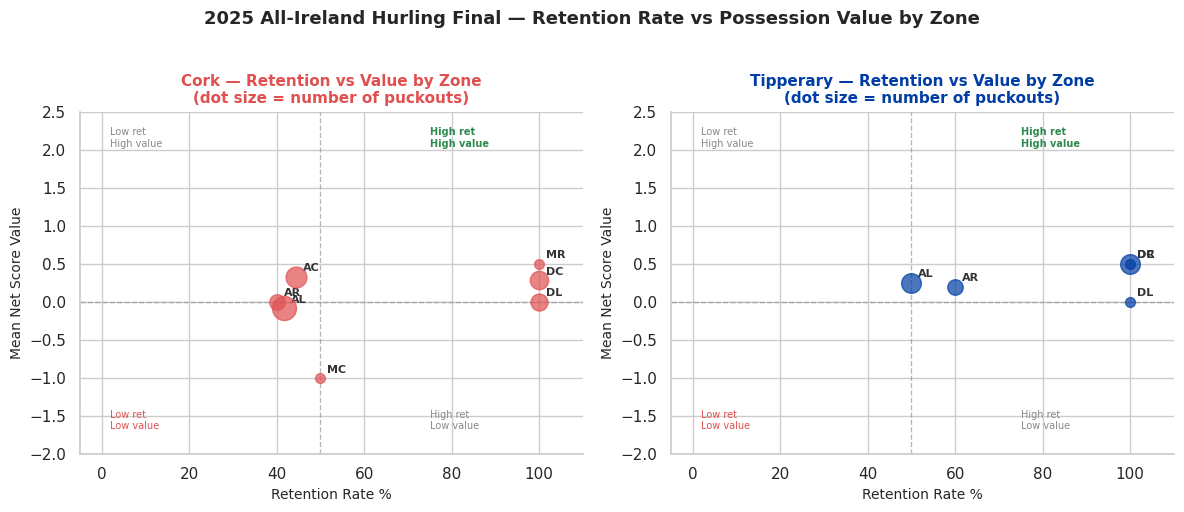

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

for ax_i, (team, col_t) in enumerate(zip(TEAMS, COLOURS)):
    sub = sub_po[team]
    ax  = axes[ax_i]
    for zone in PO_ZONES:
        s = sub[(sub['target_zone']==zone) & sub['outcome_logged']]
        if len(s) < 2:
            continue
        ret = s['retained_bool'].mean() * 100
        val = s['net_score_value'].mean()
        cnt = len(s)
        ax.scatter(ret, val, s=cnt*25, color=col_t, alpha=0.7, zorder=5)
        ax.annotate(zone, (ret, val),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=8, fontweight='bold', color='#333')

    ax.axhline(0, color=C_GREY, linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(50, color=C_GREY, linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Retention Rate %', fontsize=10)
    ax.set_ylabel('Mean Net Score Value', fontsize=10)
    ax.set_title(f'{team} — Retention vs Value by Zone\n'
                 f'(dot size = number of puckouts)',
                 fontsize=11, fontweight='bold', color=col_t)
    ax.set_xlim(-5, 110); ax.set_ylim(-2, 2.5)
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)

    # Quadrant labels
    ax.text(2, 2.3, 'Low ret\nHigh value', fontsize=7, color=C_GREY, va='top')
    ax.text(75, 2.3, 'High ret\nHigh value', fontsize=7, color=C_GREEN,
            va='top', fontweight='bold')
    ax.text(2, -1.7, 'Low ret\nLow value', fontsize=7, color=C_RED, va='bottom')
    ax.text(75, -1.7, 'High ret\nLow value', fontsize=7, color=C_GREY, va='bottom')

plt.suptitle(f'{MATCH_TITLE} — Retention Rate vs Possession Value by Zone',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MATCH_LABEL}_retention_vs_value.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

Chain rows: 66
Short-then-long: 6
Chains with shot: 28
Shot scoring rate: 54%


Cork: 4/13 short puckouts were short-then-long (31%)
Tipperary: 2/12 short puckouts were short-then-long (17%)


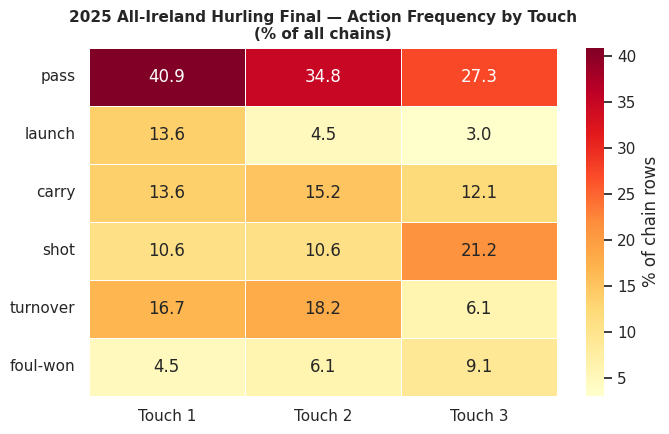

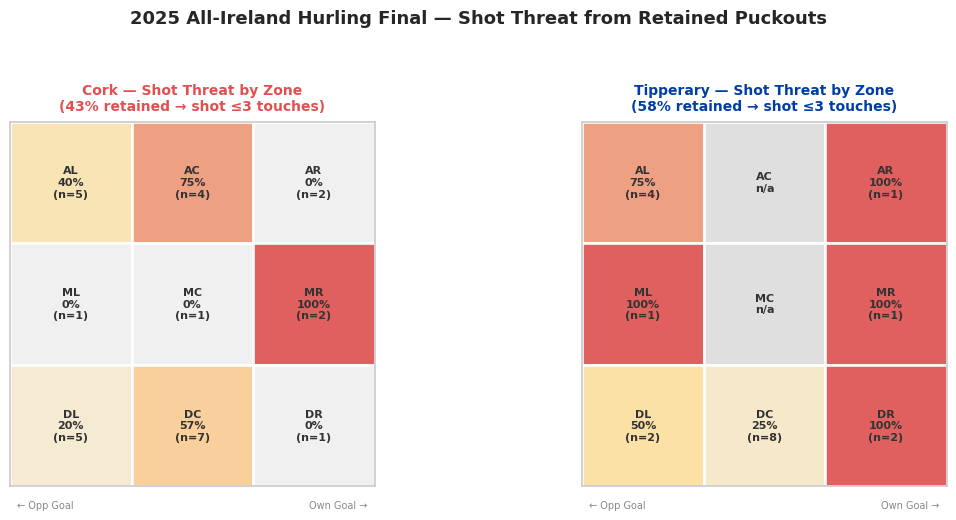

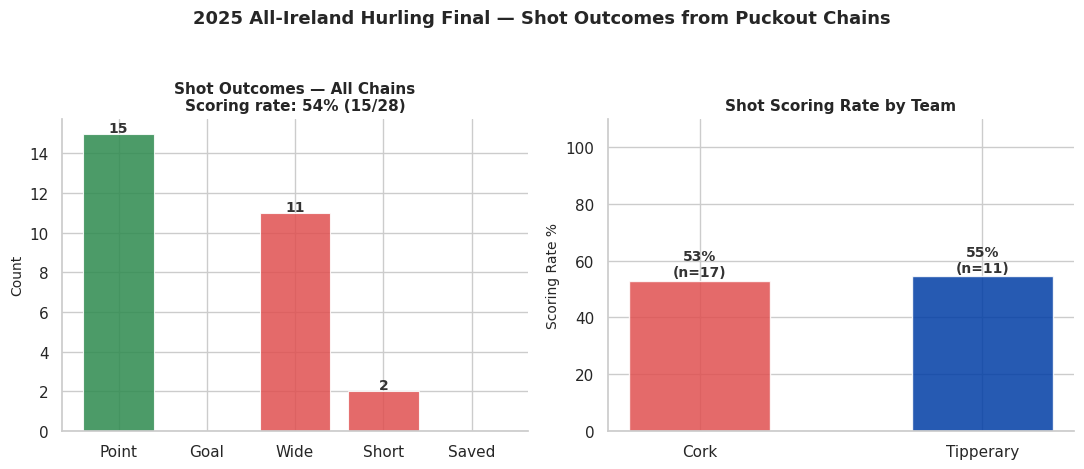

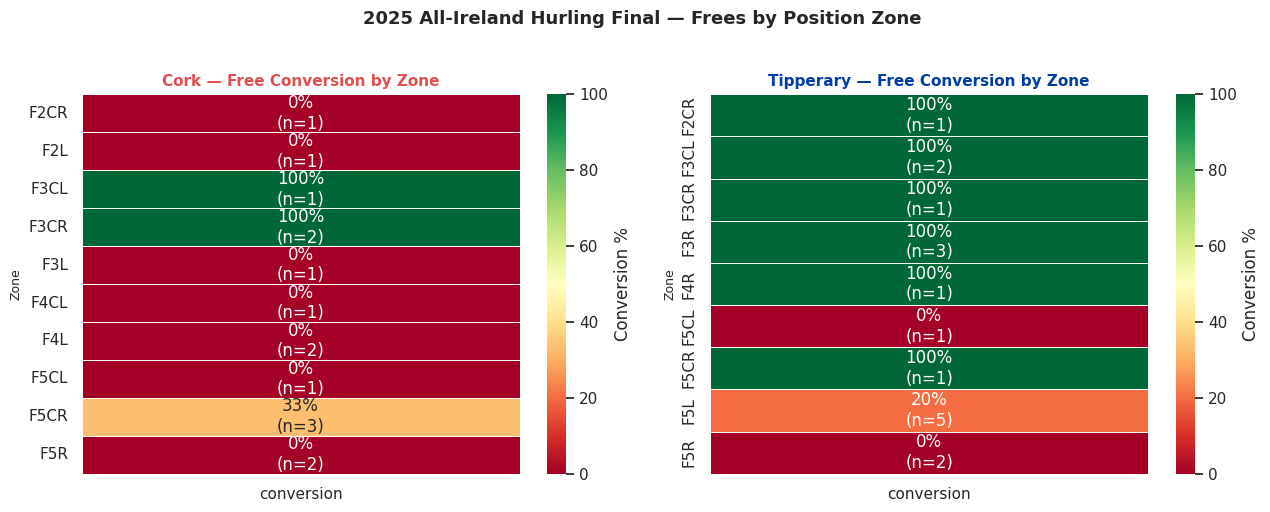

In [14]:
# TOUCH CHAIN ANALYSIS

print(f"Chain rows: {len(chain_po)}")
print(f"Short-then-long: {chain_po['is_stl'].sum()}")
print(f"Chains with shot: {chain_po['has_shot'].sum()}")
if chain_po['has_shot'].sum()>0:
    print(f"Shot scoring rate: {chain_po[chain_po['has_shot']]['shot_scored'].mean()*100:.0f}%")

# ── A: Short-then-long ───────────────────────────────────────────
stl_data = []
for team in TEAMS:
    sub = sub_chain[team][sub_chain[team]['type']=='short']
    if len(sub)==0: continue
    stl_data.append({'Team':team,'Short-then-long':int(sub['is_stl'].sum()),
                     'Genuine short':int(len(sub)-sub['is_stl'].sum()),'total':len(sub)})

if stl_data:
    df_stl = pd.DataFrame(stl_data)
    fig6   = go.Figure()
    for cat,col in [('Short-then-long',C_RED),('Genuine short',C_GREEN)]:
        fig6.add_trace(go.Bar(name=cat,x=df_stl['Team'],y=df_stl[cat],
            marker_color=col,text=df_stl[cat],textposition='inside'))
    fig6.update_layout(barmode='stack',
        title=f'<b>{MATCH_TITLE} — Short Puckout Intent</b>',
        yaxis=dict(title='Count'),
        legend=dict(orientation='h',y=1.1,x=0.5,xanchor='center'),
        height=380, **PL)
    fig6.show()
    for team in TEAMS:
        sub = sub_chain[team][sub_chain[team]['type']=='short']
        if len(sub)==0: continue
        stl = sub['is_stl'].sum()
        print(f"{team}: {stl}/{len(sub)} short puckouts were short-then-long ({stl/len(sub)*100:.0f}%)")

# ── B: Touch action heatmap ──────────────────────────────────────
touch_cols   = ['t1_action','t2_action','t3_action']
touch_labels = ['Touch 1','Touch 2','Touch 3']
all_actions  = ['pass','launch','carry','shot','turnover','foul-won']
hm_data      = pd.DataFrame(index=all_actions,columns=touch_labels,data=0.0)
total_chain  = len(chain_po)
for col,label in zip(touch_cols,touch_labels):
    counts = chain_po[col].value_counts()
    for action in all_actions:
        hm_data.loc[action,label] = counts.get(action,0)/total_chain*100

fig7,ax = plt.subplots(figsize=(7,4.5))
sns.heatmap(hm_data.astype(float),annot=True,fmt='.1f',cmap='YlOrRd',
    linewidths=0.5,linecolor='white',
    cbar_kws={'label':'% of chain rows'},ax=ax)
ax.set_title(f'{MATCH_TITLE} — Action Frequency by Touch\n(% of all chains)',
             fontsize=11,fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{MATCH_LABEL}_chain_heatmap.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

# ── C: Shot threat by zone ───────────────────────────────────────
threat_cmap = LinearSegmentedColormap.from_list('threat',['#f0f0f0','#ffe0a0','#e05050'])
fig8,axes   = plt.subplots(1,2,figsize=(12,5))
fig8.patch.set_facecolor('white')

for ax_i,(team,col_t) in enumerate(zip(TEAMS,COLOURS)):
    sub = retained_chain[retained_chain['pucking_team']==team]
    ax  = axes[ax_i]
    ax.set_facecolor(C_GRASS); ax.set_xlim(0,3); ax.set_ylim(0,3); ax.set_aspect('equal')
    for zone,(row,col) in PO_ZONES.items():
        s      = sub[sub['target_zone']==zone]
        is_nan = len(s)==0
        val    = s['has_shot'].mean() if not is_nan else np.nan
        colour = threat_cmap(val) if not is_nan else '#dddddd'
        cnt    = len(s)
        ax.add_patch(patches.Rectangle((col,2-row),1,1,
            facecolor=colour,alpha=0.9,edgecolor='white',linewidth=2))
        lbl = f"{zone}\n{val*100:.0f}%\n(n={cnt})" if not is_nan else f"{zone}\nn/a"
        ax.text(col+0.5,2-row+0.5,lbl,ha='center',va='center',
                fontsize=8,fontweight='bold',color='#333333')
    ax.set_xticks([]); ax.set_yticks([])
    overall = sub['has_shot'].mean()*100 if len(sub)>0 else 0
    ax.set_title(f'{team} — Shot Threat by Zone\n({overall:.0f}% retained → shot ≤3 touches)',
                 fontsize=10,fontweight='bold',color=col_t,pad=8)
    ax.text(0.02,-0.06,'← Opp Goal',transform=ax.transAxes,fontsize=7,color=C_GREY)
    ax.text(0.98,-0.06,'Own Goal →',transform=ax.transAxes,fontsize=7,color=C_GREY,ha='right')

plt.suptitle(f'{MATCH_TITLE} — Shot Threat from Retained Puckouts',fontsize=13,fontweight='bold',y=1.04)
plt.tight_layout()
plt.savefig(f'{MATCH_LABEL}_shot_threat.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()

# ── D: Shot outcomes ─────────────────────────────────────────────
shot_chains = chain_po[
    chain_po['has_shot'] &
    chain_po['shot_outcome'].notna() &
    ~chain_po['shot_outcome'].astype(str).isin(['','nan'])
].copy()

if len(shot_chains)>=3:
    out_order = ['point','goal','wide','short','saved']
    out_cols  = [C_GREEN,C_GOLD,C_RED,C_RED,'#e08830']
    outcomes  = shot_chains['shot_outcome'].value_counts().reindex(out_order,fill_value=0)
    fig9,axes = plt.subplots(1,2,figsize=(11,4.5))
    fig9.patch.set_facecolor('white')

    ax = axes[0]
    bars = ax.bar([o.title() for o in out_order],outcomes.values,
                  color=out_cols,alpha=0.85,edgecolor='white',linewidth=0.8)
    for bar,val in zip(bars,outcomes.values):
        if val>0: ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,
                          str(val),ha='center',fontsize=10,fontweight='bold',color='#333')
    ax.set_title(f'Shot Outcomes — All Chains\n'
                 f'Scoring rate: {shot_chains["shot_scored"].mean()*100:.0f}%'
                 f' ({shot_chains["shot_scored"].sum()}/{len(shot_chains)})',
                 fontsize=11,fontweight='bold')
    ax.set_ylabel('Count',fontsize=10)
    ax.set_facecolor('white'); ax.spines[['top','right']].set_visible(False)

    ax2 = axes[1]
    for i,(team,col) in enumerate(zip(TEAMS,COLOURS)):
        sub = shot_chains[shot_chains['pucking_team']==team]
        if len(sub)==0: continue
        rate = sub['shot_scored'].mean()*100
        ax2.bar(team,rate,color=col,alpha=0.85,edgecolor='white',width=0.5)
        ax2.text(i,rate+1.5,f'{rate:.0f}%\n(n={len(sub)})',
                 ha='center',fontsize=10,fontweight='bold',color='#333')
    ax2.set_ylabel('Scoring Rate %',fontsize=10); ax2.set_ylim(0,110)
    ax2.set_title('Shot Scoring Rate by Team',fontsize=11,fontweight='bold')
    ax2.set_facecolor('white'); ax2.spines[['top','right']].set_visible(False)

    plt.suptitle(f'{MATCH_TITLE} — Shot Outcomes from Puckout Chains',fontsize=13,fontweight='bold',y=1.04)
    plt.tight_layout()
    plt.savefig(f'{MATCH_LABEL}_shot_outcomes.png',dpi=150,bbox_inches='tight',facecolor='white')
    plt.show()
else:
    print(f"Only {len(shot_chains)} shots logged — not enough for chart yet")

# After the main frees charts in Cell 12

fr_zones = fr.groupby(['shooting_team','position_zone']).agg(
    attempts=('scored','count'),
    scored=('scored','sum')
).assign(conversion=lambda x: x.scored/x.attempts*100).reset_index()

fig_fz, axes_fz = plt.subplots(1, 2, figsize=(13, 5))
fig_fz.patch.set_facecolor('white')

for ax_i, (team, col_t) in enumerate(zip(TEAMS, COLOURS)):
    sub   = fr_zones[fr_zones['shooting_team']==team]
    ax    = axes_fz[ax_i]
    pivot = sub.pivot_table(
        index='position_zone', values=['attempts','conversion'],
        aggfunc='first').fillna(0)

    if len(pivot) > 0:
        sns.heatmap(
            pivot[['conversion']].astype(float),
            annot=pivot.apply(
                lambda row: f"{row['conversion']:.0f}%\n(n={int(row['attempts'])})",
                axis=1).values.reshape(-1,1),
            fmt='', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Conversion %'},
            ax=ax
        )
        ax.set_title(f'{team} — Free Conversion by Zone',
                     fontsize=11, fontweight='bold', color=col_t)
        ax.set_xlabel(''); ax.set_ylabel('Zone', fontsize=9)

plt.suptitle(f'{MATCH_TITLE} — Frees by Position Zone',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MATCH_LABEL}_frees_zones.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [15]:
print(f"\n{'HALF-BY-HALF BREAKDOWN':═<60}")
for half in [1, 2]:
    sub_half = po[po['half']==half]
    print(f"\n  Half {half}:")
    print(f"  {'Metric':<32} {TEAM_A:>12} {TEAM_B:>12}")
    print(f"  {'─'*56}")
    for label, col in [
        ('Puckouts',          'id'),
        ('Retention %',       'retained_bool'),
        ('Short %',           None),
        ('Long %',            None),
        ('Net score value',   'net_score_value'),
    ]:
        vals = []
        for team in TEAMS:
            s = sub_half[sub_half['pucking_team']==team]
            if label == 'Puckouts':
                vals.append(str(len(s)))
            elif label == 'Short %':
                vals.append(f"{(s['type']=='short').mean()*100:.0f}%" if len(s)>0 else '—')
            elif label == 'Long %':
                vals.append(f"{(s['type']=='long').mean()*100:.0f}%" if len(s)>0 else '—')
            elif col == 'retained_bool':
                vals.append(f"{s[col].mean()*100:.0f}%" if len(s)>0 else '—')
            elif col == 'net_score_value':
                vals.append(f"{s[col].mean():+.2f}" if len(s)>0 else '—')
        print(f"  {label:<32} {vals[0]:>12} {vals[1]:>12}")


HALF-BY-HALF BREAKDOWN══════════════════════════════════════

  Half 1:
  Metric                                   Cork    Tipperary
  ────────────────────────────────────────────────────────
  Puckouts                                   23           21
  Retention %                               78%          81%
  Short %                                   43%          48%
  Long %                                    48%          43%
  Net score value                         +0.30        +0.38

  Half 2:
  Metric                                   Cork    Tipperary
  ────────────────────────────────────────────────────────
  Puckouts                                   22            7
  Retention %                               50%          57%
  Short %                                   18%          29%
  Long %                                    68%          71%
  Net score value                         -0.18        +0.43


In [16]:
# FREES & SET PIECES

fig10 = make_subplots(rows=1,cols=3,
    subplot_titles=('<b>Score Conversion %</b>',
                    '<b>Outcome Breakdown</b>',
                    '<b>Attempt Type Conversion</b>'),
    horizontal_spacing=0.1)

for i,(team,col) in enumerate(zip(TEAMS,COLOURS)):
    conv = sub_fr[team]['scored'].mean()*100
    fig10.add_trace(go.Bar(x=[team],y=[conv],marker_color=col,
        text=[f'{conv:.0f}%'],textposition='outside',
        name=team,showlegend=False), row=1, col=1)

OUT_ORDER = ['point','goal','wide','short','saved','cleared','retained','lost']
OUT_COLS  = {'point':C_GREEN,'goal':C_GOLD,'wide':C_RED,'short':C_RED,
             'saved':'#e08830','cleared':'#e08830','retained':'#5090e0','lost':C_GREY}
for outcome in OUT_ORDER:
    vals = [len(sub_fr[t][sub_fr[t]['outcome']==outcome]) for t in TEAMS]
    if sum(vals)>0:
        fig10.add_trace(go.Bar(name=outcome.title(),x=TEAMS,y=vals,
            marker_color=OUT_COLS.get(outcome,C_GREY),showlegend=True), row=1, col=2)

att_types = fr['attempt_type'].value_counts().index.tolist()
for i,(team,col) in enumerate(zip(TEAMS,COLOURS)):
    sub   = sub_fr[team]
    convs = [sub[sub['attempt_type']==a]['scored'].mean()*100 if len(sub[sub['attempt_type']==a])>0 else 0 for a in att_types]
    ns    = [len(sub[sub['attempt_type']==a]) for a in att_types]
    fig10.add_trace(go.Bar(name=team,x=[a.title() for a in att_types],y=convs,
        marker_color=col,text=[f'{c:.0f}%<br>n={n}' for c,n in zip(convs,ns)],
        textposition='outside',offsetgroup=i,showlegend=False), row=1, col=3)

fig10.update_layout(barmode='group',
    title=f'<b>{MATCH_TITLE} — Frees & Set Pieces</b>',title_font_size=15,
    legend=dict(orientation='v',x=1.02,y=0.5),
    yaxis=dict(range=[0,110]),yaxis3=dict(range=[0,120]),
    height=440, **PL)
fig10.show()

print("\nFrees summary:")
print(fr.groupby(['shooting_team','set_piece_type']).agg(
    attempts=('scored','count'),
    scored=('scored','sum'),
    conversion=('scored',lambda x:f"{x.mean()*100:.0f}%")
).to_string())


Frees summary:
                              attempts  scored conversion
shooting_team set_piece_type                             
Cork          free                  11       4        36%
              sideline               4       0         0%
Tipperary     free                  15      10        67%
              sideline               2       0         0%


In [21]:
# ROLLING RETENTION & OUTCOME TIMELINE

fig11 = go.Figure()
for team,col,dash in zip(TEAMS,COLOURS,['solid','dash']):
    sub = sub_po[team].sort_values('minute').reset_index(drop=True)
    if len(sub)<5: continue
    # rolling(7) with min_periods=3 starts plotting once 3 rows exist
    sub['rolling_ret'] = sub['retained_bool'].rolling(7,min_periods=3).mean()*100
    fig11.add_trace(go.Scatter(x=sub['minute'],y=sub['rolling_ret'].round(1),
        mode='lines',name=f'{team} retention',
        line=dict(color=col,width=2.5,dash=dash),
        hovertemplate='Min %{x}  Ret: %{y:.0f}%<extra></extra>'))

for team,col in zip(TEAMS,COLOURS):
    sub = sub_po[team][sub_po[team]['outcome_logged']].sort_values('minute')
    fig11.add_trace(go.Scatter(x=sub['minute'],y=sub['net_score_value'],
        mode='markers',name=f'{team} outcome',
        marker=dict(
            color=sub['net_score_value'].apply(
                lambda v: C_GREEN if v>0 else (C_RED if v<0 else C_GREY)),
            size=7,opacity=0.6,
            symbol='circle' if team==TEAM_A else 'square'),
        yaxis='y2',
        hovertemplate='Min %{x}  Value: %{y}<extra></extra>'))

fig11.add_vline(x=35,line_dash='dot',line_color=C_GREY,
               annotation_text='Half Time',annotation_position='top right')
fig11.update_layout(
    title=f'<b>{MATCH_TITLE} — Rolling Retention & Outcome Timeline</b>',
    title_font_size=15,
    xaxis=dict(title='Minute'),
    yaxis=dict(title='Retention % (rolling 7)',range=[0,110]),
    yaxis2=dict(title='Net score value',overlaying='y',side='right',
                range=[-4,4],showgrid=False,zeroline=True,zerolinecolor=C_GREY),
    legend=dict(orientation='h',y=1.1,x=0.5,xanchor='center'),
    height=430, **PL)
fig11.show()

po['period'] = pd.cut(po['minute'],
    bins=[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75],
    labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35',
            '35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75'])

period_data = po.groupby(['pucking_team','period'])['net_score_value'].agg(
    ['mean','count','sum']).reset_index()
period_data.columns = ['Team','Period','Mean Value','Count','Total Value']

fig = make_subplots(rows=1, cols=2,
    subplot_titles=(f'<b>{TEAM_A}</b>', f'<b>{TEAM_B}</b>'))

for col_i, (team, col) in enumerate(zip(TEAMS, COLOURS), 1):
    sub = period_data[period_data['Team']==team]
    bar_cols = sub['Mean Value'].apply(
        lambda v: C_GREEN if v > 0 else (C_RED if v < 0 else C_GREY))
    fig.add_trace(go.Bar(
        x=sub['Period'], y=sub['Mean Value'],
        marker_color=bar_cols,
        text=[f"n={int(r['Count'])}" for _,r in sub.iterrows()],
        textposition='outside',
        name=team, showlegend=False,
    ), row=1, col=col_i)

fig.add_hline(y=0, line_dash='solid', line_color=C_GREY, line_width=1)
fig.update_layout(
    title=f'<b>{MATCH_TITLE} — Puckout Value by 10-Minute Period</b>',
    yaxis=dict(title='Mean net score value', range=[-2,2]),
    yaxis2=dict(title='Mean net score value', range=[-2,2]),
    height=400, **PL)
fig.show()

In [18]:
# KEY FINDINGS SUMMARY

W = 64
print("="*W)
print(f"  {MATCH_TITLE.upper()}")
print(f"  {RESULT}")
print("="*W)

print(f"\n{'PUCKOUTS':─<{W}}")
print(f"  {'Metric':<36} {TEAM_A:>12} {TEAM_B:>12}")
print(f"  {'─'*60}")
for label,a,b in [
    ("Puckouts",
     len(sub_po[TEAM_A]),len(sub_po[TEAM_B])),
    ("Overall retention",
     f"{sub_po[TEAM_A]['retained_bool'].mean()*100:.0f}%",
     f"{sub_po[TEAM_B]['retained_bool'].mean()*100:.0f}%"),
    ("Short / retention",
     f"{(sub_po[TEAM_A]['type']=='short').sum()} / {sub_po[TEAM_A][sub_po[TEAM_A]['type']=='short']['retained_bool'].mean()*100:.0f}%",
     f"{(sub_po[TEAM_B]['type']=='short').sum()} / {sub_po[TEAM_B][sub_po[TEAM_B]['type']=='short']['retained_bool'].mean()*100:.0f}%"),
    ("Long / retention",
     f"{(sub_po[TEAM_A]['type']=='long').sum()} / {sub_po[TEAM_A][sub_po[TEAM_A]['type']=='long']['retained_bool'].mean()*100:.0f}%",
     f"{(sub_po[TEAM_B]['type']=='long').sum()} / {sub_po[TEAM_B][sub_po[TEAM_B]['type']=='long']['retained_bool'].mean()*100:.0f}%"),
    ("Broken deliveries",
     f"{(sub_po[TEAM_A]['delivery']=='B').sum()} ({(sub_po[TEAM_A]['delivery']=='B').mean()*100:.0f}%)",
     f"{(sub_po[TEAM_B]['delivery']=='B').sum()} ({(sub_po[TEAM_B]['delivery']=='B').mean()*100:.0f}%)"),
    ("Net score value (mean / total)",
     f"{sub_po[TEAM_A]['net_score_value'].mean():+.2f} / {sub_po[TEAM_A]['net_score_value'].sum():+.0f}",
     f"{sub_po[TEAM_B]['net_score_value'].mean():+.2f} / {sub_po[TEAM_B]['net_score_value'].sum():+.0f}"),
    ("Top target zone",
     sub_po[TEAM_A]['target_zone'].mode()[0],
     sub_po[TEAM_B]['target_zone'].mode()[0]),
]:
    print(f"  {label:<36} {str(a):>12} {str(b):>12}")

short_a = sub_chain[TEAM_A][sub_chain[TEAM_A]['type']=='short']
short_b = sub_chain[TEAM_B][sub_chain[TEAM_B]['type']=='short']
print(f"\n{'TOUCH CHAIN':─<{W}}")
print(f"  {'Metric':<36} {TEAM_A:>12} {TEAM_B:>12}")
print(f"  {'─'*60}")
for label,a,b in [
    ("Chain coverage",
     f"{len(sub_chain[TEAM_A])}/{len(sub_po[TEAM_A])}",
     f"{len(sub_chain[TEAM_B])}/{len(sub_po[TEAM_B])}"),
    ("Short-then-long",
     f"{short_a['is_stl'].sum()}/{len(short_a)} ({short_a['is_stl'].mean()*100:.0f}%)" if len(short_a) else "—",
     f"{short_b['is_stl'].sum()}/{len(short_b)} ({short_b['is_stl'].mean()*100:.0f}%)" if len(short_b) else "—"),
    ("Retained → shot rate",
     f"{retained_chain[retained_chain['pucking_team']==TEAM_A]['has_shot'].mean()*100:.0f}%" if len(retained_chain[retained_chain['pucking_team']==TEAM_A])>0 else "—",
     f"{retained_chain[retained_chain['pucking_team']==TEAM_B]['has_shot'].mean()*100:.0f}%" if len(retained_chain[retained_chain['pucking_team']==TEAM_B])>0 else "—"),
]:
    print(f"  {label:<36} {str(a):>12} {str(b):>12}")

print(f"\n{'FREES':─<{W}}")
print(f"  {'Metric':<36} {TEAM_A:>12} {TEAM_B:>12}")
print(f"  {'─'*60}")
for label,a,b in [
    ("Attempts",len(sub_fr[TEAM_A]),len(sub_fr[TEAM_B])),
    ("Score conversion",
     f"{sub_fr[TEAM_A]['scored'].mean()*100:.0f}%",
     f"{sub_fr[TEAM_B]['scored'].mean()*100:.0f}%"),
    ("Points / goals",
     f"{(sub_fr[TEAM_A]['outcome']=='point').sum()} / {(sub_fr[TEAM_A]['outcome']=='goal').sum()}",
     f"{(sub_fr[TEAM_B]['outcome']=='point').sum()} / {(sub_fr[TEAM_B]['outcome']=='goal').sum()}"),
    ("Wides / shorts",
     (sub_fr[TEAM_A]['outcome'].isin(['wide','short'])).sum(),
     (sub_fr[TEAM_B]['outcome'].isin(['wide','short'])).sum()),
]:
    print(f"  {label:<36} {str(a):>12} {str(b):>12}")

if CONTEXT_NOTE:
    print(f"\n{'CONTEXT':─<{W}}")
    words = CONTEXT_NOTE.split()
    line,lines = '',[]
    for w in words:
        if len(line)+len(w)+1<=W-4: line+=(' ' if line else '')+w
        else: lines.append(line); line=w
    if line: lines.append(line)
    for l in lines: print(f"  {l}")

print("="*W)
print("\nNote: These are process metrics. Match outcomes are additionally")
print("influenced by open-play goal-scoring and defensive structure,")
print("which are outside the scope of this dataset.")

  2025 ALL-IRELAND HURLING FINAL
  Tipperary 3-27  Cork 1-18 (Tipp Win)

PUCKOUTS────────────────────────────────────────────────────────
  Metric                                       Cork    Tipperary
  ────────────────────────────────────────────────────────────
  Puckouts                                       45           28
  Overall retention                             64%          75%
  Short / retention                       14 / 100%    12 / 100%
  Long / retention                         26 / 42%     14 / 50%
  Broken deliveries                        12 (27%)      4 (14%)
  Net score value (mean / total)         +0.07 / +3  +0.39 / +11
  Top target zone                                AL           AL

TOUCH CHAIN─────────────────────────────────────────────────────
  Metric                                       Cork    Tipperary
  ────────────────────────────────────────────────────────────
  Chain coverage                              41/45        25/28
  Short-then-long   